In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

In [ ]:
stroke = pd.read_csv('stroke.csv')
stroke

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43395,56196,Female,10.0,0,0,No,children,Urban,58.64,20.4,never smoked,0
43396,5450,Female,56.0,0,0,Yes,Govt_job,Urban,213.61,55.4,formerly smoked,0
43397,28375,Female,82.0,1,0,Yes,Private,Urban,91.94,28.9,formerly smoked,0
43398,27973,Male,40.0,0,0,Yes,Private,Urban,99.16,33.2,never smoked,0


In [ ]:
stroke = stroke.iloc[:, 1:32]
stroke

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
43395,Female,10.0,0,0,No,children,Urban,58.64,20.4,never smoked,0
43396,Female,56.0,0,0,Yes,Govt_job,Urban,213.61,55.4,formerly smoked,0
43397,Female,82.0,1,0,Yes,Private,Urban,91.94,28.9,formerly smoked,0
43398,Male,40.0,0,0,Yes,Private,Urban,99.16,33.2,never smoked,0


In [ ]:
stroke.work_type.unique()

array(['children', 'Private', 'Never_worked', 'Self-employed', 'Govt_job'],
      dtype=object)

In [ ]:
stroke.isnull().sum()

gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

In [ ]:
bmi_mean = stroke.bmi.mean()
stroke.bmi = stroke.bmi.fillna(bmi_mean)

In [ ]:
stroke.smoking_status.unique()

array([nan, 'never smoked', 'formerly smoked', 'smokes'], dtype=object)

In [ ]:
stroke.smoking_status.value_counts()

never smoked       16053
formerly smoked     7493
smokes              6562
Name: smoking_status, dtype: int64

In [ ]:
stroke.smoking_status = stroke.smoking_status.fillna('unknown')

In [ ]:
stroke.smoking_status.value_counts()

never smoked       16053
unknown            13292
formerly smoked     7493
smokes              6562
Name: smoking_status, dtype: int64

In [ ]:
pd.options.mode.chained_assignment = None

In [ ]:
le = LabelEncoder()

In [ ]:
stroke.gender = le.fit_transform(stroke['gender'])
stroke.ever_married = le.fit_transform(stroke['ever_married'])
stroke.work_type = le.fit_transform(stroke['work_type'])
stroke.Residence_type = le.fit_transform(stroke['Residence_type'])
stroke.smoking_status = le.fit_transform(stroke['smoking_status'])
stroke

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,3.0,0,0,0,4,0,95.12,18.0,3,0
1,1,58.0,1,0,1,2,1,87.96,39.2,1,0
2,0,8.0,0,0,0,2,1,110.89,17.6,3,0
3,0,70.0,0,0,1,2,0,69.04,35.9,0,0
4,1,14.0,0,0,0,1,0,161.28,19.1,3,0
...,...,...,...,...,...,...,...,...,...,...,...
43395,0,10.0,0,0,0,4,1,58.64,20.4,1,0
43396,0,56.0,0,0,1,0,1,213.61,55.4,0,0
43397,0,82.0,1,0,1,2,1,91.94,28.9,0,0
43398,1,40.0,0,0,1,2,1,99.16,33.2,1,0


In [ ]:
stroke.dtypes

gender                 int32
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int32
work_type              int32
Residence_type         int32
avg_glucose_level    float64
bmi                  float64
smoking_status         int32
stroke                 int64
dtype: object

In [ ]:
stroke.stroke.value_counts()

0    42617
1      783
Name: stroke, dtype: int64

In [ ]:
x = stroke.drop(['stroke'], axis = 1)
y = stroke['stroke']

In [ ]:
mutual_info = mutual_info_classif(x,y)
mutual_info = pd.Series(mutual_info)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

age                  0.015396
ever_married         0.007015
work_type            0.006855
bmi                  0.004132
smoking_status       0.003817
heart_disease        0.003383
avg_glucose_level    0.002748
hypertension         0.002273
Residence_type       0.002156
gender               0.001933
dtype: float64

In [ ]:
stroke.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000
mean,0.408894,42.217894,0.093571,0.047512,0.643733,2.185438,0.501290,104.482750,28.605038,1.591083,0.018041
std,0.492151,22.519649,0.291235,0.212733,0.478901,1.093158,0.500004,43.111751,7.638023,1.095247,0.133103
min,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,10.100000,0.000000,0.000000
25%,0.000000,24.000000,0.000000,0.000000,0.000000,2.000000,0.000000,77.540000,23.400000,1.000000,0.000000
50%,0.000000,44.000000,0.000000,0.000000,1.000000,2.000000,1.000000,91.580000,28.100000,1.000000,0.000000
75%,1.000000,60.000000,0.000000,0.000000,1.000000,3.000000,1.000000,112.070000,32.600000,3.000000,0.000000
max,2.000000,82.000000,1.000000,1.000000,1.000000,4.000000,1.000000,291.050000,97.600000,3.000000,1.000000


C:\Users\nitis\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\nitis\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\nitis\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-lev

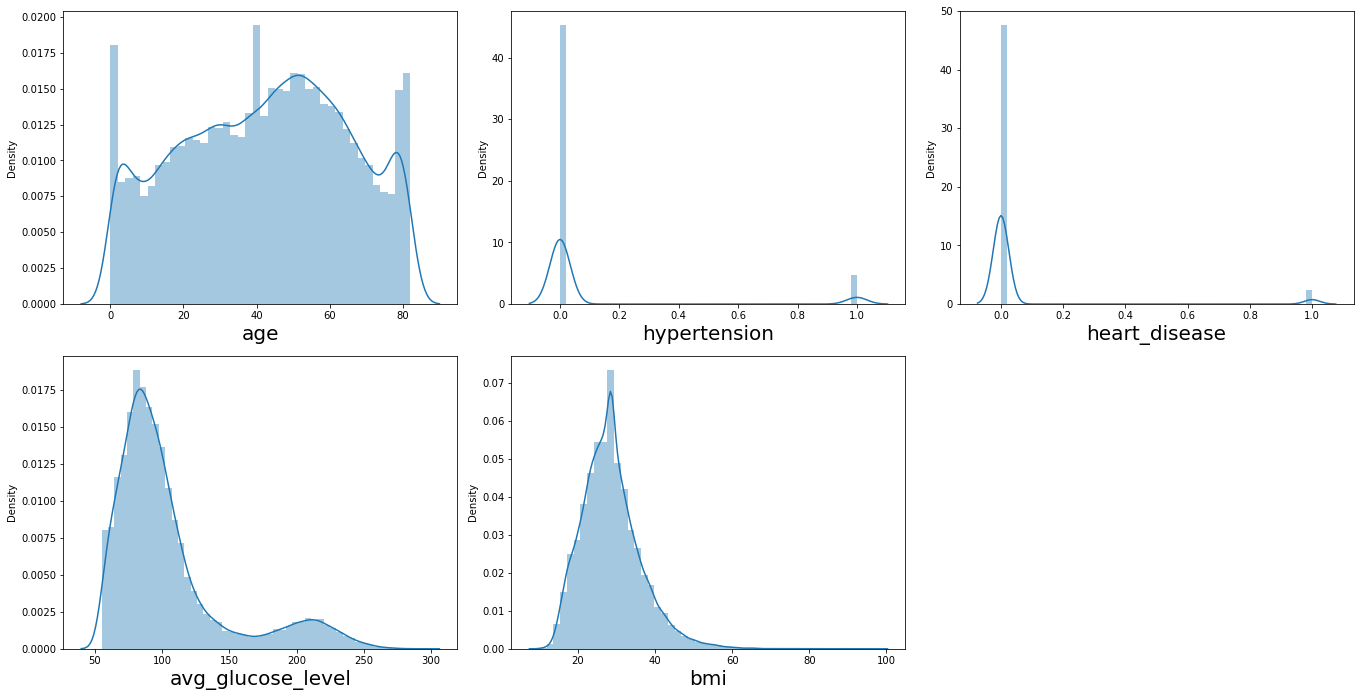

In [ ]:
cols = stroke[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']]
plt.figure(figsize=(19,14))
plot_number = 1

for column in cols:
    if plot_number <= 15:
        ax = plt.subplot(3,3,plot_number)
        sns.distplot(cols[column])
        plt.xlabel(column, fontsize=20)

    plot_number+=1
plt.tight_layout()

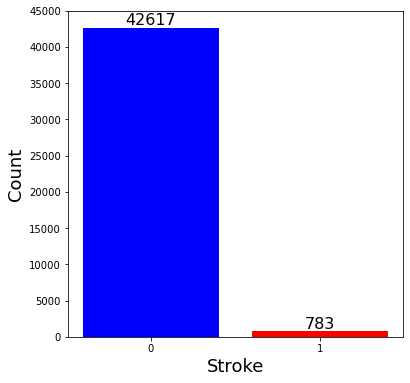

In [ ]:
plt.figure(figsize=(6,6))
names = ["0", "1"]
count = [(stroke.stroke.values == 0).sum(), (stroke.stroke.values == 1).sum()]
plt.bar(names, count, color = ["Blue", "Red"])
plt.xlabel('Stroke', fontsize= 18)
plt.ylabel('Count', fontsize= 18)
plt.ylim(0,45000)
for i in range(len(names)):
    plt.text(i, count[i], count[i], ha='center', va='bottom', fontsize=16)
plt.show()

<AxesSubplot:>

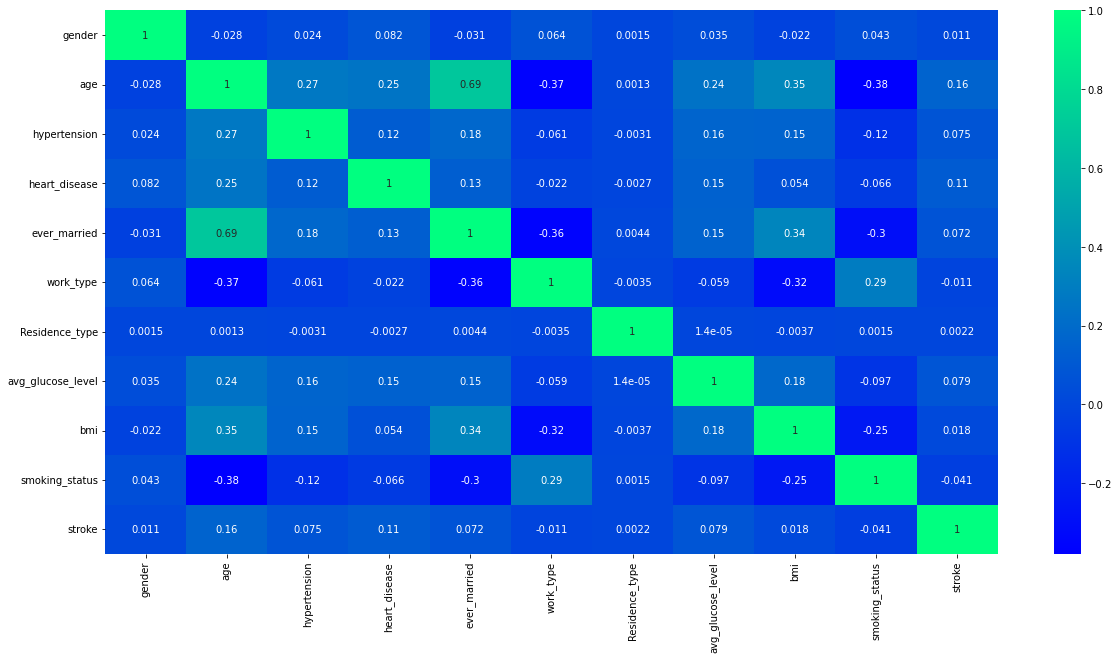

In [ ]:
plt.figure(figsize = (20, 10))
sns.heatmap(stroke.corr(), annot = True, cmap="winter")

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.35)

# Support Vector Machine (SVM)
svm = SVC().fit(x_train, y_train)

# Random Forest (RF)
RF = RandomForestClassifier().fit(x_train, y_train)

#K-nearest neighbors (KNN)
KNN = KNeighborsClassifier().fit(x_train, y_train)

# Decision Tree (DT)
DT = DecisionTreeClassifier().fit(x_train, y_train)

# Naive Bayes (NB)
NB = GaussianNB().fit(x_train, y_train)

# Logistic Regression (LR)
LR = LogisticRegression(solver='liblinear',max_iter=3000).fit(x_train, y_train)

# AdaBoostClassifier (AB)
AB = AdaBoostClassifier().fit(x_train, y_train)

# GradientBoostingClassifier (GB)
GB = GradientBoostingClassifier().fit(x_train, y_train)

# Multi-layer perceptron (MLP)
MLP = MLPClassifier().fit(x_train, y_train)

# Nearest Centroid Classifier (NCC)
NCC = NearestCentroid().fit(x_train, y_train)

# Voting Classifier (VC)
est = [('svm',svm), ('lr',LR)]
VC = VotingClassifier(estimators = est, voting ='hard').fit(x_train, y_train)

In [ ]:
# Support Vector Machine (SVM)
svm_pre = svm.predict(x_test)
svm_sc = svm.score(x_test, y_test) * 100
svm_sc = "{:.2f}".format(svm_sc)

# Random Forest (RF)
rf_pre = RF.predict(x_test)
RF_sc = RF.score(x_test, y_test) * 100
RF_sc = "{:.2f}".format(RF_sc)

#K-nearest neighbors (KNN)
knn_pre = KNN.predict(x_test)
KNN_sc = KNN.score(x_test, y_test) * 100
KNN_sc = "{:.2f}".format(KNN_sc)

# Decision Tree (DT)
dt_pre = DT.predict(x_test)
DT_sc = DT.score(x_test, y_test) * 100
DT_sc = "{:.2f}".format(DT_sc)

# Naive Bayes (NB)
nb_pre = NB.predict(x_test)
NB_sc = NB.score(x_test, y_test) * 100
NB_sc = "{:.2f}".format(NB_sc)

# Logistic Regression (LR)
lr_pre = LR.predict(x_test)
LR_sc = LR.score(x_test, y_test) * 100
LR_sc = "{:.2f}".format(LR_sc)

# AdaBoostClassifier (AB)
ab_pre = AB.predict(x_test)
AB_sc = AB.score(x_test, y_test) * 100
AB_sc = "{:.2f}".format(AB_sc)

# GradientBoostingClassifier (GB)
gb_pre = GB.predict(x_test)
GB_sc = GB.score(x_test, y_test) * 100
GB_sc = "{:.2f}".format(GB_sc)

# Multi-layer perceptron (MLP)
mlp_pre = MLP.predict(x_test)
MLP_sc = MLP.score(x_test, y_test) * 100
MLP_sc = "{:.2f}".format(MLP_sc)

# Nearest Centroid Classifier (NCC)
ncc_pre = NCC.predict(x_test)
NCC_sc = NCC.score(x_test, y_test) * 100
NCC_sc = "{:.2f}".format(NCC_sc)

# Voting Classifier (VC)
vc_pre = VC.predict(x_test)
vc_sc = VC.score(x_test, y_test) * 100
vc_sc = "{:.2f}".format(vc_sc)

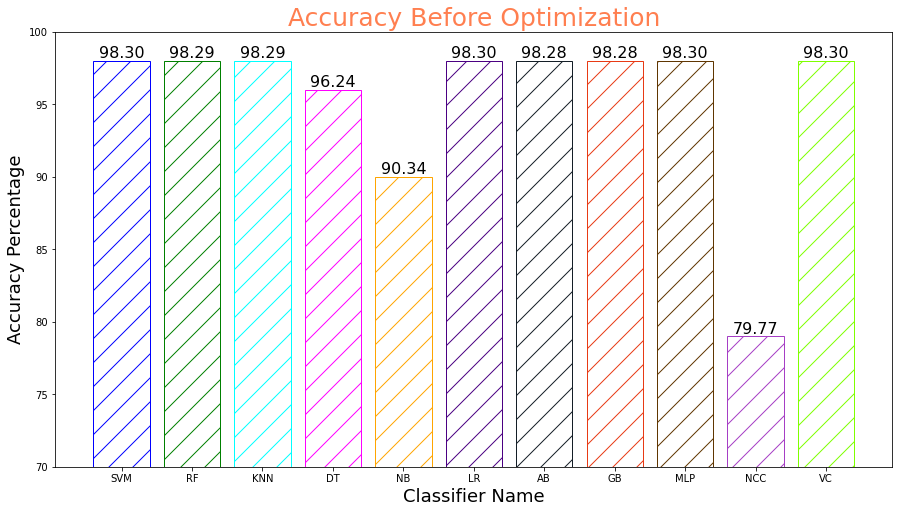

In [ ]:
plt.figure(figsize=(15,8))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC', 'VC']
acc = [math.floor(int(float(svm_sc))),math.floor(int(float(RF_sc))),math.floor(int(float(KNN_sc))),math.floor(int(float(DT_sc))),math.floor(int(float(NB_sc))),math.floor(int(float(LR_sc))),math.floor(int(float(AB_sc))),math.floor(int(float(GB_sc))),math.floor(int(float(MLP_sc))),math.floor(int(float(NCC_sc))),math.floor(int(float(vc_sc)))]
pert = [svm_sc, RF_sc, KNN_sc, DT_sc, NB_sc, LR_sc, AB_sc, GB_sc, MLP_sc, NCC_sc, vc_sc]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5', 'chartreuse']
plt.bar(algo, acc,color='white', edgecolor=colors, hatch='/')
plt.title('Accuracy Before Optimization', color = 'coral', fontsize= 25)
plt.xlabel('Classifier Name', fontsize= 18)
plt.ylabel('Accuracy Percentage', fontsize= 18)
plt.ylim(70,100)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

In [ ]:
os = RandomOverSampler(0.70)
x_os, y_os = os.fit_resample(x,y)
print("Before fit {}".format(Counter(y)))
print("After fit {}".format(Counter(y_os)))

NameError: name 'RandomOverSampler' is not defined

In [ ]:
#Support Vector Machine (SVM)
svm = SVC(C= 0.1, gamma= 1, kernel= 'rbf')
svm_y_pre = cross_val_predict(svm, x_os, y_os, cv=5)
svm_sc = accuracy_score(y_os, svm_y_pre) * 100
svm_sc = "{:.2f}".format(svm_sc)

# Random Forest (RF)
RF = RandomForestClassifier()
rf_y_pre = cross_val_predict(RF, x_os, y_os, cv=5)
RF_sc = accuracy_score(y_os, rf_y_pre) * 100
RF_sc = "{:.2f}".format(RF_sc)

#K-nearest neighbors (KNN)
KNN = KNeighborsClassifier(n_neighbors= 1, weights= 'uniform')
knn_y_pre = cross_val_predict(KNN, x_os, y_os, cv=5)
KNN_sc = accuracy_score(y_os, knn_y_pre) * 100
KNN_sc = "{:.2f}".format(KNN_sc)

# Decision Tree (DT)
DT = DecisionTreeClassifier(criterion= 'gini', max_depth= 20, min_samples_leaf= 5)
dt_y_pre = cross_val_predict(DT, x_os, y_os, cv=5)
DT_sc = accuracy_score(y_os, dt_y_pre) * 100
DT_sc = "{:.2f}".format(DT_sc)

# Naive Bayes (NB)
NB = GaussianNB()
nb_y_pre = cross_val_predict(NB, x_os, y_os, cv=5)
NB_sc = accuracy_score(y_os, nb_y_pre) * 100
NB_sc = "{:.2f}".format(NB_sc)

# Logistic Regression (LR)
LR = LogisticRegression(max_iter=3000,C= 1.0, penalty= 'l2', solver= 'liblinear')
lr_y_pre = cross_val_predict(LR, x_os, y_os, cv=5)
LR_sc = accuracy_score(y_os, lr_y_pre) * 100
LR_sc = "{:.2f}".format(LR_sc)

# AdaBoostClassifier (AB)
AB = AdaBoostClassifier()
ab_y_pre = cross_val_predict(AB, x_os, y_os, cv=5)
AB_sc = accuracy_score(y_os, ab_y_pre) * 100
AB_sc = "{:.2f}".format(AB_sc)

# GradientBoostingClassifier (GB)
GB = GradientBoostingClassifier()
gb_y_pre = cross_val_predict(GB, x_os, y_os, cv=5)
GB_sc = accuracy_score(y_os, gb_y_pre) * 100
GB_sc = "{:.2f}".format(GB_sc)

# Multi-layer perceptron (MLP)
MLP = MLPClassifier(max_iter=3000)
mlp_y_pre = cross_val_predict(MLP, x_os, y_os, cv=5)
MLP_sc = accuracy_score(y_os, mlp_y_pre) * 100
MLP_sc = "{:.2f}".format(MLP_sc)

# Nearest Centroid Classifier (NCC)
NCC = NearestCentroid()
ncc_y_pre = cross_val_predict(NCC, x_os, y_os, cv=5)
NCC_sc = accuracy_score(y_os, ncc_y_pre) * 100
NCC_sc = "{:.2f}".format(NCC_sc)

# Voting Classifier (VC)
est = [('svm',svm), ('lr',LR)]
vot_hard = VotingClassifier(estimators = est, voting ='hard')
vc_y_pre = cross_val_predict(vot_hard, x_os, y_os, cv=5)
vc_sc = accuracy_score(y_os, vc_y_pre) * 100
vc_sc = "{:.2f}".format(vc_sc)

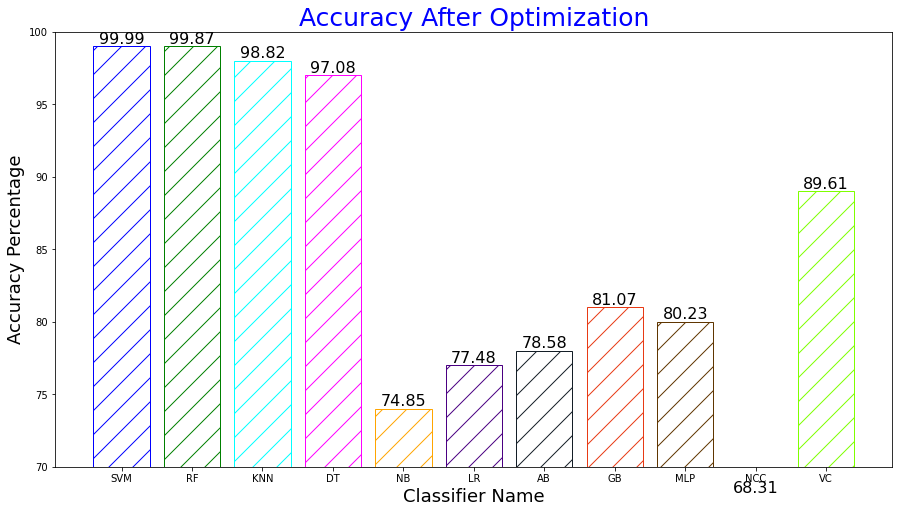

In [ ]:
plt.figure(figsize=(15,8))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC', 'VC']
acc = [math.floor(int(float(svm_sc))),math.floor(int(float(RF_sc))),math.floor(int(float(KNN_sc))),math.floor(int(float(DT_sc))),math.floor(int(float(NB_sc))),math.floor(int(float(LR_sc))),math.floor(int(float(AB_sc))),math.floor(int(float(GB_sc))),math.floor(int(float(MLP_sc))),math.floor(int(float(NCC_sc))),math.floor(int(float(vc_sc)))]
pert = [svm_sc, RF_sc, KNN_sc, DT_sc, NB_sc, LR_sc, AB_sc, GB_sc, MLP_sc, NCC_sc, vc_sc]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5', 'chartreuse']
plt.bar(algo, acc,color='white', edgecolor=colors, hatch='/')
plt.title('Accuracy After Optimization', color = 'blue', fontsize= 25)
plt.xlabel('Classifier Name', fontsize= 18)
plt.ylabel('Accuracy Percentage', fontsize= 18)
plt.ylim(70,100)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

In [ ]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = (7,4), fontsize=14, title = "Confusion Matrix"):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cmap='winter')
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=90, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=0, ha='center', fontsize=fontsize)
    plt.ylabel('Actual', fontsize=18, color='blue')
    plt.xlabel('Prediction',  fontsize=18, color='blue')
    plt.title(title, fontsize=22, color='blue')

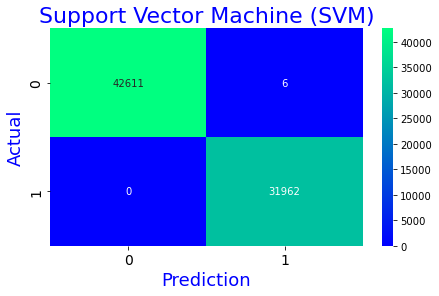

In [ ]:
cm = confusion_matrix(y_os, svm_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Support Vector Machine (SVM)")

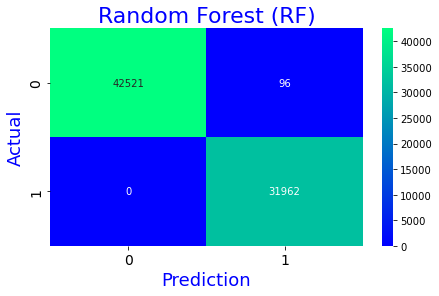

In [ ]:
cm = confusion_matrix(y_os, rf_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Random Forest (RF)")

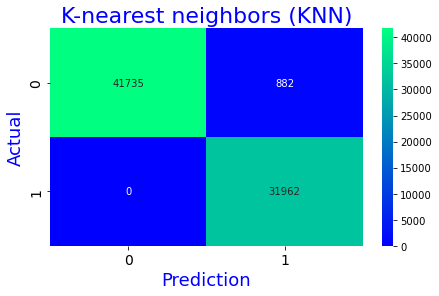

In [ ]:
cm = confusion_matrix(y_os, knn_y_pre)
print_confusion_matrix(cm,["0", "1"], title="K-nearest neighbors (KNN)")

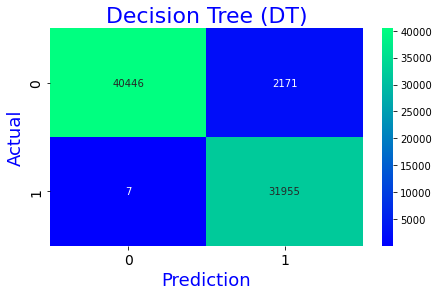

In [ ]:
cm = confusion_matrix(y_os, dt_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Decision Tree (DT)")

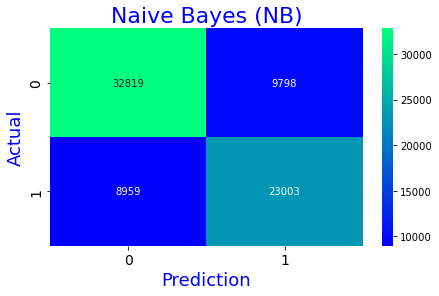

In [ ]:
cm = confusion_matrix(y_os, nb_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Naive Bayes (NB)")

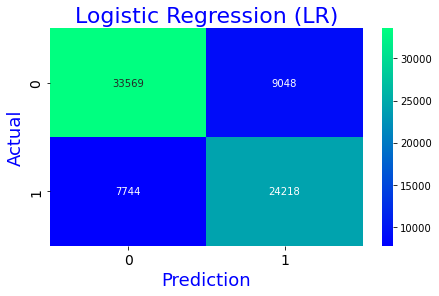

In [ ]:
cm = confusion_matrix(y_os, lr_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Logistic Regression (LR)")

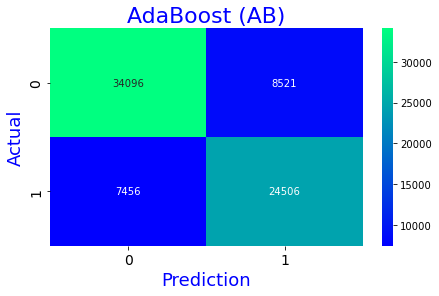

In [ ]:
cm = confusion_matrix(y_os, ab_y_pre)
print_confusion_matrix(cm,["0", "1"], title="AdaBoost (AB)")

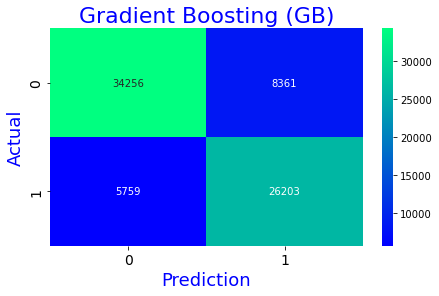

In [ ]:
cm = confusion_matrix(y_os, gb_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Gradient Boosting (GB)")

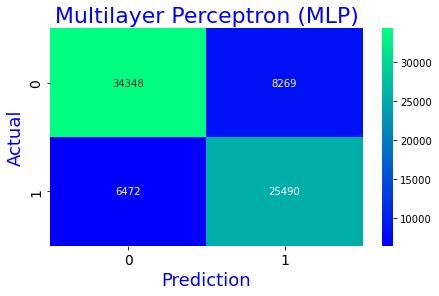

In [ ]:
cm = confusion_matrix(y_os, mlp_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Multilayer Perceptron (MLP)")

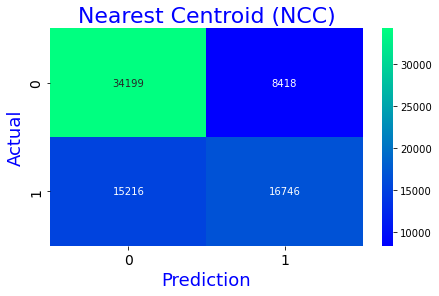

In [ ]:
cm = confusion_matrix(y_os, ncc_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Nearest Centroid (NCC)")

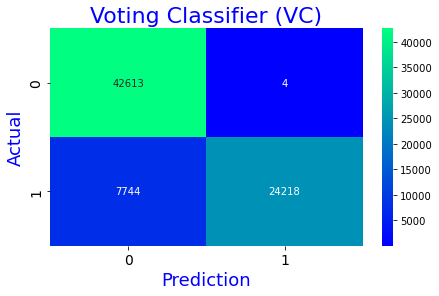

In [ ]:
cm = confusion_matrix(y_os, vc_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Voting Classifier (VC)")

In [ ]:
pd.DataFrame(classification_report(y_os, svm_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.999812,0.99992,0.999906,0.99992
recall,0.999859,1.000000,0.99992,0.999930,0.99992
f1-score,0.999930,0.999906,0.99992,0.999918,0.99992
support,42617.000000,31962.000000,0.99992,74579.000000,74579.00000


In [ ]:
pd.DataFrame(classification_report(y_os, rf_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.997005,0.998713,0.998503,0.998717
recall,0.997747,1.000000,0.998713,0.998874,0.998713
f1-score,0.998872,0.998500,0.998713,0.998686,0.998713
support,42617.000000,31962.000000,0.998713,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, knn_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.973146,0.988174,0.986573,0.988491
recall,0.979304,1.000000,0.988174,0.989652,0.988174
f1-score,0.989544,0.986390,0.988174,0.987967,0.988192
support,42617.000000,31962.000000,0.988174,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, dt_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.999827,0.936383,0.970796,0.968105,0.972637
recall,0.949058,0.999781,0.970796,0.974419,0.970796
f1-score,0.973781,0.967044,0.970796,0.970413,0.970894
support,42617.000000,31962.000000,0.970796,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, nb_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.785557,0.701290,0.748495,0.743423,0.749443
recall,0.770092,0.719698,0.748495,0.744895,0.748495
f1-score,0.777747,0.710375,0.748495,0.744061,0.748874
support,42617.000000,31962.000000,0.748495,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, lr_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.812553,0.728011,0.774843,0.770282,0.776321
recall,0.787690,0.757712,0.774843,0.772701,0.774843
f1-score,0.799929,0.742565,0.774843,0.771247,0.775344
support,42617.000000,31962.000000,0.774843,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, ab_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.820562,0.741999,0.785771,0.781281,0.786893
recall,0.800056,0.766723,0.785771,0.783390,0.785771
f1-score,0.810180,0.754158,0.785771,0.782169,0.786171
support,42617.000000,31962.000000,0.785771,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, gb_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.856079,0.758101,0.810671,0.807090,0.814089
recall,0.803811,0.819817,0.810671,0.811814,0.810671
f1-score,0.829122,0.787752,0.810671,0.808437,0.811392
support,42617.000000,31962.000000,0.810671,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, mlp_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.841450,0.755058,0.802344,0.798254,0.804425
recall,0.805969,0.797510,0.802344,0.801739,0.802344
f1-score,0.823328,0.775703,0.802344,0.799516,0.802918
support,42617.000000,31962.000000,0.802344,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, ncc_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.692077,0.665474,0.683101,0.678776,0.680676
recall,0.802473,0.523935,0.683101,0.663204,0.683101
f1-score,0.743198,0.586283,0.683101,0.664740,0.675950
support,42617.000000,31962.000000,0.683101,74579.000000,74579.000000


In [ ]:
pd.DataFrame(classification_report(y_os, vc_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.846218,0.999835,0.89611,0.923026,0.912053
recall,0.999906,0.757712,0.89611,0.878809,0.896110
f1-score,0.916665,0.862096,0.89611,0.889380,0.893279
support,42617.000000,31962.000000,0.89611,74579.000000,74579.000000


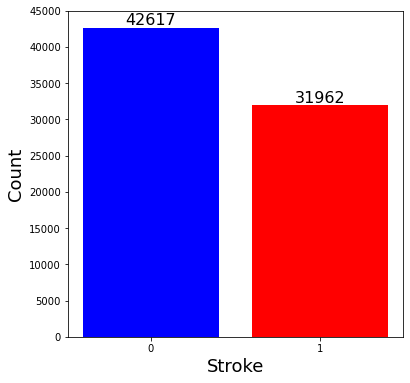

In [ ]:
plt.figure(figsize=(6,6))
names = ["0", "1"]
count = [(y_os.values == 0).sum(), (y_os.values == 1).sum()]
plt.bar(names, count, color = ["Blue", "Red"])
plt.xlabel('Stroke', fontsize= 18)
plt.ylabel('Count', fontsize= 18)
plt.ylim(0,45000)
for i in range(len(names)):
    plt.text(i, count[i], count[i], ha='center', va='bottom', fontsize=16)
plt.show()